In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib.cm as cm
import json
import os

In [2]:
SAVE_PLOTS = True

In [3]:
# Define the file path based on your n and m values
n = 50
m = 2
file_path = f"../results/n{n}_m{m}_comparison.jld2"

In [4]:
plt.style.use("default")
plt.style.use("../../config/unified_plots.mplstyle")
with open("../../config/unified_plots.json", "r") as f:
    plot_args = json.load(f)

In [5]:
os.makedirs("../plots", exist_ok=True)

In [6]:
# Data parameters
NTP_VALUES = [5, 10, 25, 50, 100, 250]  # Values displayed in the top left of each subplot
NSHOTS_OBS = np.arange(10) + 1  # Observation shots from 1 to 10 (log-scale)
NSHOTS_PREDS = np.arange(10) + 1  # Prediction shots from 1 to 10 (log-scale)

# names
METRIC_NAME = "mse"

# settings:
WIDTH_INCHES = plot_args["fig_width_inches_full"]
SHOTSOBS = plot_args["macros"]["shotsobs"]
SHOTSPRED = plot_args["macros"]["shotsker"]

In [7]:
bench_args = plot_args["benchmarking"]
macros = plot_args["macros"]

# Define method groups
QUANTUM_METHODS = ['gp', 'gp_active', 'hl', 'param']
BASELINE_METHODS = ['mean', 'lin', 'cub']
ALL_METHODS = QUANTUM_METHODS + BASELINE_METHODS

# Extract common kwargs (linewidth, alpha, markersize)
common_kw = bench_args.get("common_plot_kwargs", {})

# Build the master configuration dictionary
plot_configs = {}
for method in ALL_METHODS:
    # 1. Get method-specific properties
    spec_kw = bench_args["methods"].get(method, {}).copy()
    
    # 2. Inherit base properties for the standard GP
    if method == "gp":
        base_gp = plot_args["gp_mean"].copy()
        base_gp.update(spec_kw)
        spec_kw = base_gp
        
    # 3. Merge common kwargs with specific kwargs
    final_kw = {**common_kw, **spec_kw}
    
    # 4. Pop out non-plotting attributes so ax.plot() doesn't crash
    cmap_name = final_kw.pop("cmap", "viridis")
    label = final_kw.pop("label", method)
    
    # 5. Store everything cleanly
    plot_configs[method] = {
        "kwargs": final_kw,                  # Clean dict for **kwargs unpacking
        "cmap": cm.get_cmap(cmap_name),      # Colormap object for Plot 2
        "label": label,                      # Formatted label
        "marker": final_kw.get("marker", "o"),
        "linestyle": final_kw.get("linestyle", "-")
    }


/var/folders/7_/vz1nj3hx5psd4x1v80v8lrch0000gn/T/ipykernel_85250/2518302055.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  "cmap": cm.get_cmap(cmap_name),      # Colormap object for Plot 2


In [8]:
import numpy as np
from juliacall import Main as jl

def load_jld2_to_dict(filepath):
    """
    Uses Julia natively via juliacall to load a JLD2 file, bypassing HDF5 pointer issues.
    Returns a pure, nested Python dictionary containing NumPy arrays.
    """
    # 1. Load the JLD2 module in the embedded Julia instance
    jl.seval("using JLD2")
    JLD2 = jl.seval("JLD2")
    
    # 2. Load the object natively. 
    # Note: JLD2's `load_object` natively unpacks 'single_stored_object' for us!
    raw_julia_data = JLD2.load_object(filepath)
    
    # 3. Recursively convert Julia Dicts and Arrays to pure Python/NumPy types
    def _convert_to_python(obj):
        # If it acts like a dictionary (Julia Dicts expose .items() via juliacall)
        if hasattr(obj, "items"):
            return {key: _convert_to_python(val) for key, val in obj.items()}
        
        # If it acts like an array (Julia Arrays expose .shape via juliacall)
        elif hasattr(obj, "shape") and hasattr(obj, "dtype"):
            return np.array(obj)
            
        # Fallback for primitive scalars (ints, floats, strings)
        else:
            return obj

    return _convert_to_python(raw_julia_data)

data = load_jld2_to_dict(file_path)

print("Data loaded successfully!")
# You can now safely run: method_data = data["metrics"][ntp][f"{method}_{METRIC_NAME}"]

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Data loaded successfully!


# MSE vs Number of Training Points (ntp)

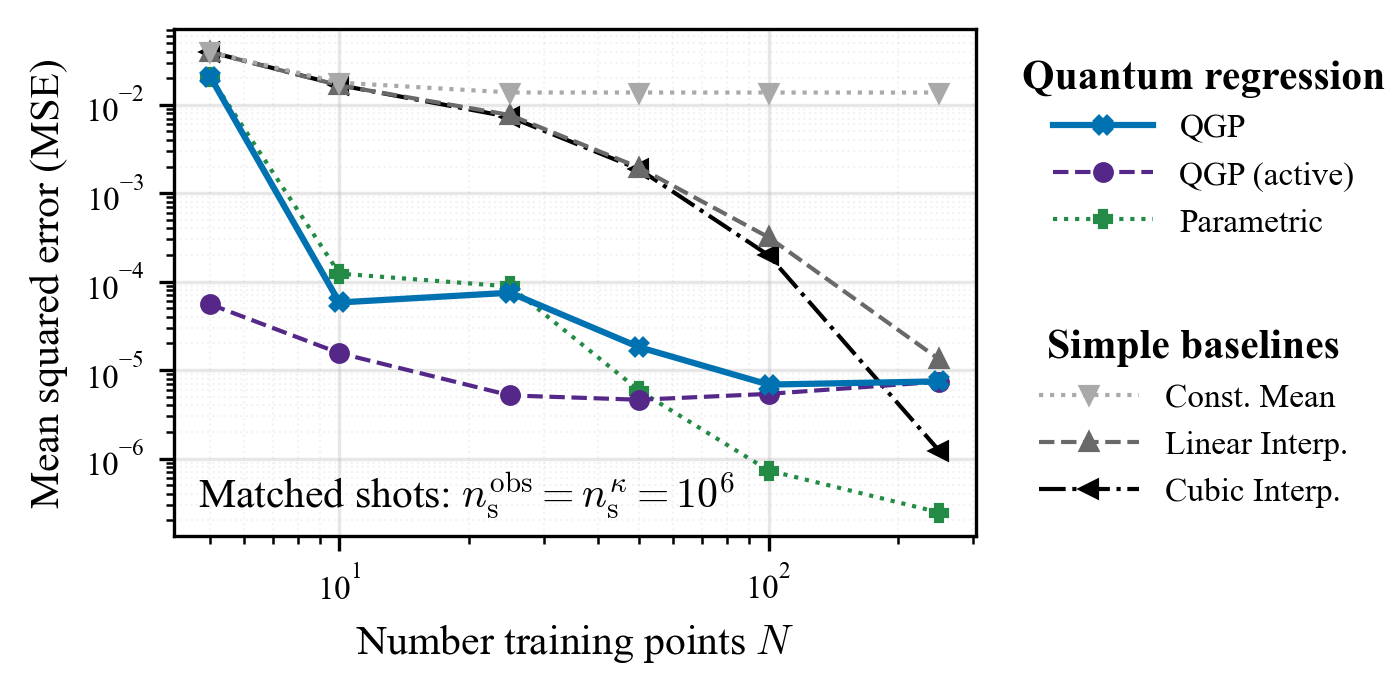

In [9]:
RED_WIDTH_INCHES = WIDTH_INCHES * 0.67
HEIGHT_INCHES = 2.2
TARGET_OBS_IDX = 5 
TARGET_PRED_IDX = 5
EXLUDED_METHODS = ["hl"]

# Assuming `data` exists in your environment
NTP_VALUES_ALL = sorted(data["ntps"])

fig, ax = plt.subplots(figsize=(RED_WIDTH_INCHES, HEIGHT_INCHES), layout="constrained")

actual_obs_idx_used = 0
actual_pred_idx_used = 0
handles_dict = {}

for method in reversed(ALL_METHODS):
    # Skip if method is excluded (like hl in your original snippet) but keep it safe
    if method not in plot_configs or method in EXLUDED_METHODS: continue
        
    y_values = []
    valid_ntps = []
    
    for ntp in NTP_VALUES_ALL:
        metric_key = f"{method}_mse"
        if metric_key in data["metrics"][ntp]:
            mse_matrix = np.array(data["metrics"][ntp][metric_key])
            
            safe_obs_idx = min(TARGET_OBS_IDX, mse_matrix.shape[0] - 1)
            safe_pred_idx = min(TARGET_PRED_IDX, mse_matrix.shape[1] - 1)
            actual_obs_idx_used, actual_pred_idx_used = safe_obs_idx, safe_pred_idx
            
            y_values.append(mse_matrix[safe_obs_idx, safe_pred_idx])
            valid_ntps.append(ntp)
            
    if valid_ntps:
        # Pass the pre-processed **kwargs dictionary cleanly
        line, = ax.plot(valid_ntps, y_values, label=plot_configs[method]["label"], **plot_configs[method]["kwargs"])
        handles_dict[method] = line

# Format axes directly from JSON definitions
ax_config = bench_args["axes"]
ax.set_xlabel(ax_config["xlabel_ntp"])
ax.set_ylabel(ax_config["ylabel_mse"])
ax.set_xscale(ax_config["xscale"])
ax.set_yscale(ax_config["yscale"])
ax.grid(True, **ax_config["grid_major"])
ax.grid(True, **ax_config["grid_minor"])


# Dynamic Title
assert actual_obs_idx_used == actual_pred_idx_used
obs_label = str(10**(actual_obs_idx_used + 1)) 
obs_label = f"10^{{{actual_obs_idx_used + 1}}}"
# pred_label = str(10**(actual_pred_idx_used + 1))
shot_text = f"Matched shots: ${macros['shotsobs']} = {macros['shotsker']} = {obs_label}$"
ax.text(
    0.03, 0.03,          # x, y (4% margin from the bottom and left spines)
    shot_text, 
    transform=ax.transAxes, 
    horizontalalignment='left', 
    verticalalignment='bottom'
)

# Legends
quantum_handles = [handles_dict[m] for m in QUANTUM_METHODS if m in handles_dict]
baseline_handles = [handles_dict[m] for m in BASELINE_METHODS if m in handles_dict]

legend1 = ax.legend(handles=quantum_handles, loc='upper left', bbox_to_anchor=(1.02, 1.0), 
                    frameon=False, title="Quantum regression", title_fontproperties={'weight': 'bold'}, handlelength=3)
ax.add_artist(legend1)

legend2 = ax.legend(handles=baseline_handles, loc='upper left', bbox_to_anchor=(1.02, 0.5), 
                    frameon=False, title="Simple baselines", title_fontproperties={'weight': 'bold'}, handlelength=3, 
                    borderaxespad=1.0)

#if SAVE_PLOTS:
#    plt.savefig("../plots/mse_vs_ntp_with_baselines.pdf")
plt.show()

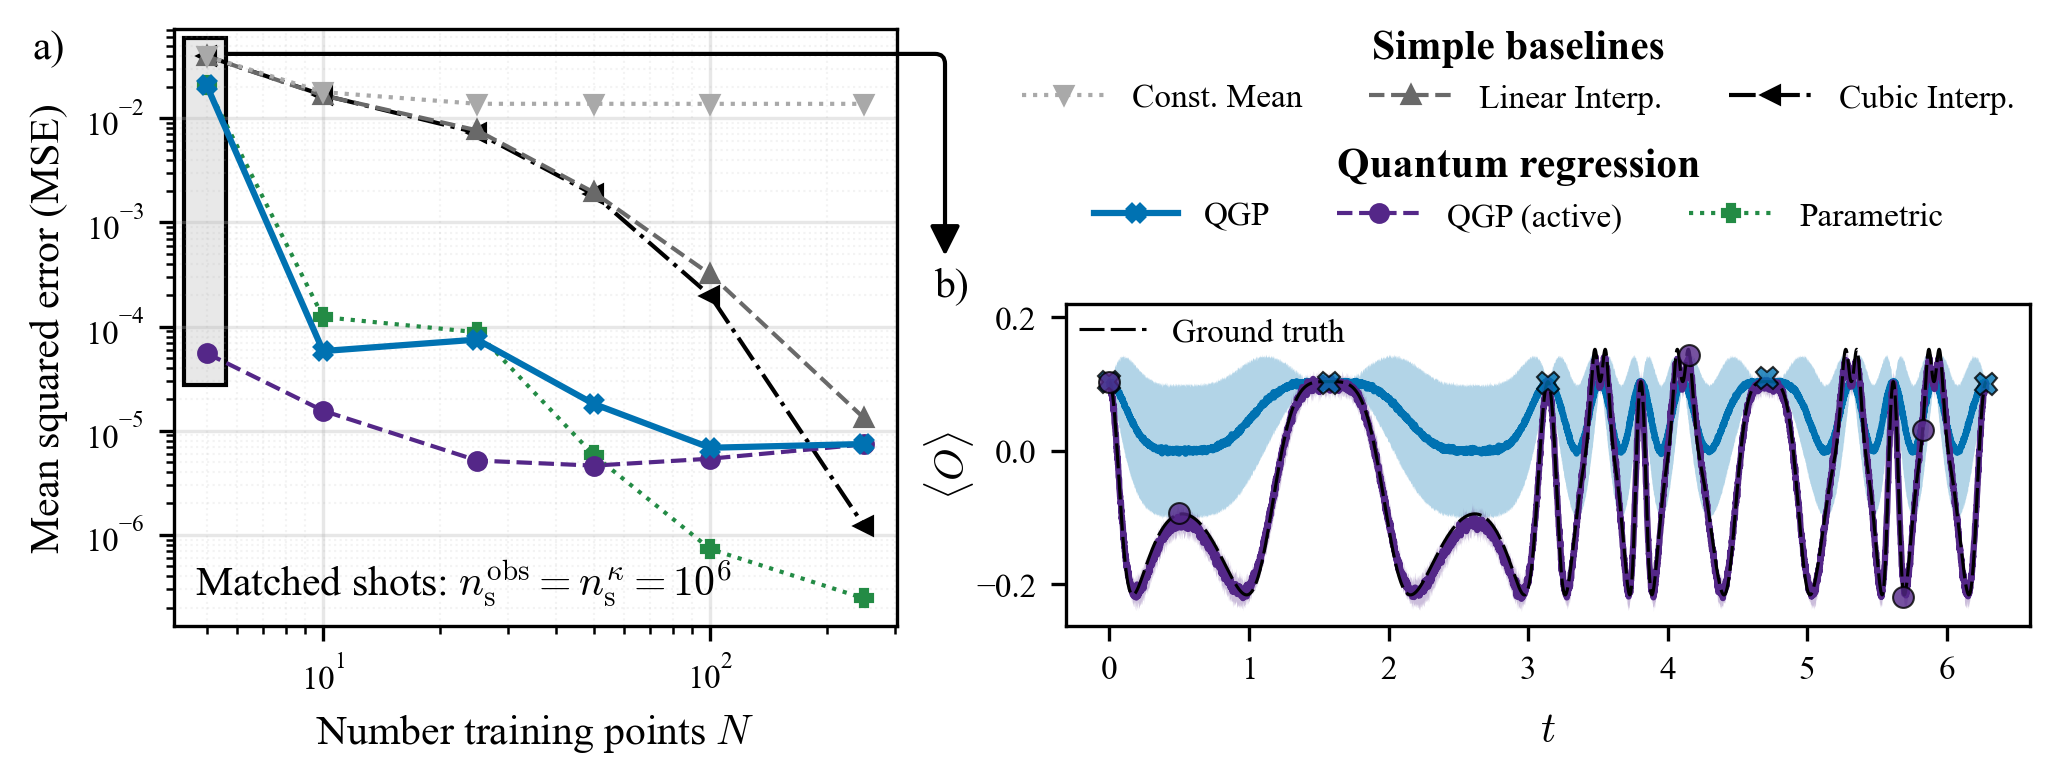

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Rectangle
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# Figure configuration
FULL_WIDTH_INCHES = plot_args["fig_width_inches_full"]
HEIGHT_INCHES = 2.5
TARGET_OBS_IDX = 5 
TARGET_PRED_IDX = 5
EXLUDED_METHODS = ["hl"]
N_TRAIN_TARGET = 5 # The specific N value you want for the right panel

# 1. Implement GridSpec for asymmetric heights
fig = plt.figure(figsize=(FULL_WIDTH_INCHES, HEIGHT_INCHES), layout="constrained")
gs = fig.add_gridspec(2, 2, width_ratios=[0.75, 1], height_ratios=[0.7, 1])

label_font_size = plt.rcParams["axes.labelsize"]

# ==========================================
# PANEL A: Benchmark Plot (Left, Full Height)
# ==========================================
ax_left = fig.add_subplot(gs[:, 0]) 
NTP_VALUES_ALL = sorted(data["ntps"])

actual_obs_idx_used = 0
actual_pred_idx_used = 0
handles_dict = {}

for method in reversed(ALL_METHODS):
    if method not in plot_configs or method in EXLUDED_METHODS: continue
        
    y_values = []
    valid_ntps = []
    
    for ntp in NTP_VALUES_ALL:
        metric_key = f"{method}_mse"
        if metric_key in data["metrics"][ntp]:
            mse_matrix = np.array(data["metrics"][ntp][metric_key])
            
            safe_obs_idx = min(TARGET_OBS_IDX, mse_matrix.shape[0] - 1)
            safe_pred_idx = min(TARGET_PRED_IDX, mse_matrix.shape[1] - 1)
            actual_obs_idx_used, actual_pred_idx_used = safe_obs_idx, safe_pred_idx
            
            y_values.append(mse_matrix[safe_obs_idx, safe_pred_idx])
            valid_ntps.append(ntp)
            
    if valid_ntps:
        line, = ax_left.plot(valid_ntps, y_values, label=plot_configs[method]["label"], **plot_configs[method]["kwargs"])
        handles_dict[method] = line

ax_config = bench_args["axes"]
ax_left.set_xlabel(ax_config["xlabel_ntp"])
ax_left.set_ylabel(ax_config["ylabel_mse"])
ax_left.set_xscale(ax_config["xscale"])
ax_left.set_yscale(ax_config["yscale"])
ax_left.grid(True, **ax_config["grid_major"])
ax_left.grid(True, **ax_config["grid_minor"])

# Dynamic Title
assert actual_obs_idx_used == actual_pred_idx_used
obs_label = f"10^{{{actual_obs_idx_used + 1}}}"
shot_text = f"Matched shots: ${macros['shotsobs']} = {macros['shotsker']} = {obs_label}$"
ax_left.text(0.03, 0.03, shot_text, transform=ax_left.transAxes, 
             horizontalalignment='left', verticalalignment='bottom')

# Panel label 'a)'
ax_left.text(-0.15, 1.0, "a)", transform=ax_left.transAxes, 
             verticalalignment="top", horizontalalignment="right",
             fontsize=label_font_size, in_layout=False)


# ==========================================
# PANEL B: Regression Trajectory (Right, Bottom)
# ==========================================
ax_right = fig.add_subplot(gs[1, 1]) 

jld2_path = f"../results/preds/n{n}_m{m}/ntp_{N_TRAIN_TARGET}/obs_{10**TARGET_OBS_IDX}_pred_{10**TARGET_PRED_IDX}/run_1.jld2"
regression_data = load_jld2_to_dict(jld2_path)

ts = np.array(regression_data["ts"])
true_outputs = np.array(regression_data["true_outputs"])
train_idxs = np.array(regression_data["train_idxs"]) - 1 
test_idxs = np.array(regression_data["test_idxs"]) - 1

y_obs = np.array(regression_data["y_obs"])
σ_obs = np.array(regression_data["σ_obs"])

gp_mu = np.array(regression_data["gp_mu"])
gp_sigma = np.array(regression_data["gp_sigma"])

gp_active_mu = np.array(regression_data["gp_active_mu"])
gp_active_sigma = np.array(regression_data["gp_active_sigma"])
y_active_obs    = np.array(regression_data["y_active_obs"])
σ_active_obs    = np.array(regression_data["σ_active_obs"]) 
train_active_idxs = np.array(regression_data["train_active_idxs"]) - 1
test_active_idxs  = np.array(regression_data["test_active_idxs"]) - 1

t_train = ts[train_idxs]
t_test = ts[sorted(test_idxs)]

# 1. True Dynamics
true_line = ax_right.plot(ts, true_outputs, **plot_args["true_function"])[0]

# --- DYNAMIC COLOR SYNCING ---
# Extract the exact colors used in the left plot to guarantee 100% consistency
gp_base_color = handles_dict["gp"].get_color() if "gp" in handles_dict else plot_configs["gp"]["kwargs"].get("color", "blue")
gp_act_color = handles_dict["gp_active"].get_color() if "gp_active" in handles_dict else plot_configs["gp_active"]["kwargs"].get("color", "purple")

# Fetch base GP styles from JSON
gp_stds_kwargs = plot_args["gp_stds"].copy()
gp_stds_kwargs["color"] = gp_base_color
if "facecolor" in gp_stds_kwargs: gp_stds_kwargs["facecolor"] = gp_base_color

gp_mean_kwargs = plot_args["gp_mean"].copy()
gp_mean_kwargs["label"] = plot_configs["gp"]["label"]
gp_mean_kwargs["color"] = gp_base_color

# 2. Standard GP Prediction
ax_right.fill_between(t_test, gp_mu - gp_sigma, gp_mu + gp_sigma, **gp_stds_kwargs)
ax_right.plot(t_test, gp_mu, **gp_mean_kwargs) 

# 3. Active GP Prediction
gp_act_conf = plot_configs["gp_active"]

gp_act_stds_kwargs = gp_stds_kwargs.copy()
gp_act_stds_kwargs["color"] = gp_act_color
if "facecolor" in gp_act_stds_kwargs: gp_act_stds_kwargs["facecolor"] = gp_act_color

gp_act_mean_kwargs = gp_mean_kwargs.copy()
gp_act_mean_kwargs["color"] = gp_act_color
gp_act_mean_kwargs["label"] = gp_act_conf["label"]

ax_right.fill_between(ts[test_active_idxs], gp_active_mu - gp_active_sigma, gp_active_mu + gp_active_sigma, **gp_act_stds_kwargs)
ax_right.plot(ts[test_active_idxs], gp_active_mu, **gp_act_mean_kwargs)

# 4. Training Points
obs_kwargs = plot_args["observations"].copy()
obs_kwargs["zorder"] = 5
# 4.a Base GP training points
obs_kwargs["markersize"] = 5.5
obs_kwargs["color"] = gp_base_color
obs_kwargs["marker"] = plot_configs["gp"]["marker"]
ax_right.plot(t_train, y_obs, **obs_kwargs)
# 4.b Active learning GP training points
obs_kwargs["markersize"] = 5
obs_kwargs["color"] = gp_act_color
obs_kwargs["marker"] = gp_act_conf["marker"]
ax_right.plot(ts[train_active_idxs], y_active_obs, **obs_kwargs)

# Format axes using JSON arguments
ax_right.set_xlabel(plot_args["regression"]["xlabel"])
ax_right.set_ylabel(plot_args["regression"]["ylabel"], labelpad=0)

# Panel label 'b)'
ax_right.text(-0.1, 1.0, "b)", transform=ax_right.transAxes, 
              verticalalignment="bottom", horizontalalignment="right",
              fontsize=label_font_size, in_layout=False)

# Add headroom and single-entry legend
ymin, ymax = ax_right.get_ylim()
ax_right.set_ylim(ymin, 0.22)  
ax_right.legend(handles=[true_line], loc="upper left", frameon=False, borderaxespad=0.0)


# ==========================================
# STACKED TOP LEGENDS (Right, Top)
# ==========================================
ax_leg = fig.add_subplot(gs[0, 1])
ax_leg.axis("off")

quantum_handles = [handles_dict[m] for m in QUANTUM_METHODS if m in handles_dict]
baseline_handles = [handles_dict[m] for m in BASELINE_METHODS if m in handles_dict]

leg1 = ax_leg.legend(handles=quantum_handles, loc='lower center', bbox_to_anchor=(0.47, 0.1), 
                     frameon=False, title="Quantum regression", title_fontproperties={'weight': 'bold'}, 
                     borderaxespad=0.0, borderpad=0.0, handlelength=2.5, ncol=3)
ax_leg.add_artist(leg1)

if baseline_handles:
    leg2 = ax_leg.legend(handles=baseline_handles, loc='upper center', bbox_to_anchor=(0.47, 1.), 
                         frameon=False, title="Simple baselines", title_fontproperties={'weight': 'bold'}, 
                         borderaxespad=0.0, borderpad=0.0, handlelength=2.5, ncol=3)


# ==========================================
# CONNECTING ARROW & DATA FRAME
# ==========================================
y_at_target = []
for line in handles_dict.values():
    x_data = np.array(line.get_xdata())
    y_data = np.array(line.get_ydata())
    
    mask = (x_data == N_TRAIN_TARGET)
    if np.any(mask):
        idx = np.where(mask)[0][0]
        y_at_target.append(y_data[idx])

if y_at_target:
    ymin_target, ymax_target = min(y_at_target), max(y_at_target)
    
    rect_y = ymin_target * 0.5  
    rect_top = ymax_target * 1.5 
    rect_height = rect_top - rect_y
    
    rect_width = N_TRAIN_TARGET * 0.25
    rect_x = N_TRAIN_TARGET - (rect_width / 2)

    fill_color_with_alpha = mcolors.to_rgba("lightgray", alpha=0.5)
    frame = Rectangle((rect_x, rect_y), rect_width, rect_height,
                      facecolor=fill_color_with_alpha, 
                      edgecolor="black", linestyle="-", linewidth=1.0, zorder=1)
    ax_left.add_patch(frame)

    # ---------------------------------------------------------
    # ARROW STYLES (Uncomment the one you want to use)
    # ---------------------------------------------------------
    
    # Style 1: High sweeping arc (Default)
    #style = "arc3,rad=-0.4"
    
    # Style 2: Sharp 90-degree corner (Up from box, right to the plot)
    #style = "angle,angleA=90,angleB=180,rad=0"
    
    # Style 3: Rounded 90-degree corner
    style = "angle,angleA=90,angleB=180,rad=10"
    
    # Style 4: Step (Creates a bracket shape bridging the plots)
    #style = "bar,fraction=0.2"

    arrow = ConnectionPatch(
        xyB=(N_TRAIN_TARGET + rect_width / 2, rect_top - rect_height * 0.3), coordsB=ax_left.transData, 
        xyA=(-0.125, 1.15), coordsA=ax_right.transAxes,                      
        color="black",
        arrowstyle="<|-", 
        mutation_scale=15, 
        linewidth=1.0, 
        linestyle="-", 
        connectionstyle=style 
    )
    fig.add_artist(arrow)

fig.align_xlabels()

if SAVE_PLOTS:
    plt.savefig("../plots/mse_vs_ntp_and_trajectory.pdf", bbox_inches="tight")
plt.show()

# Small multiples

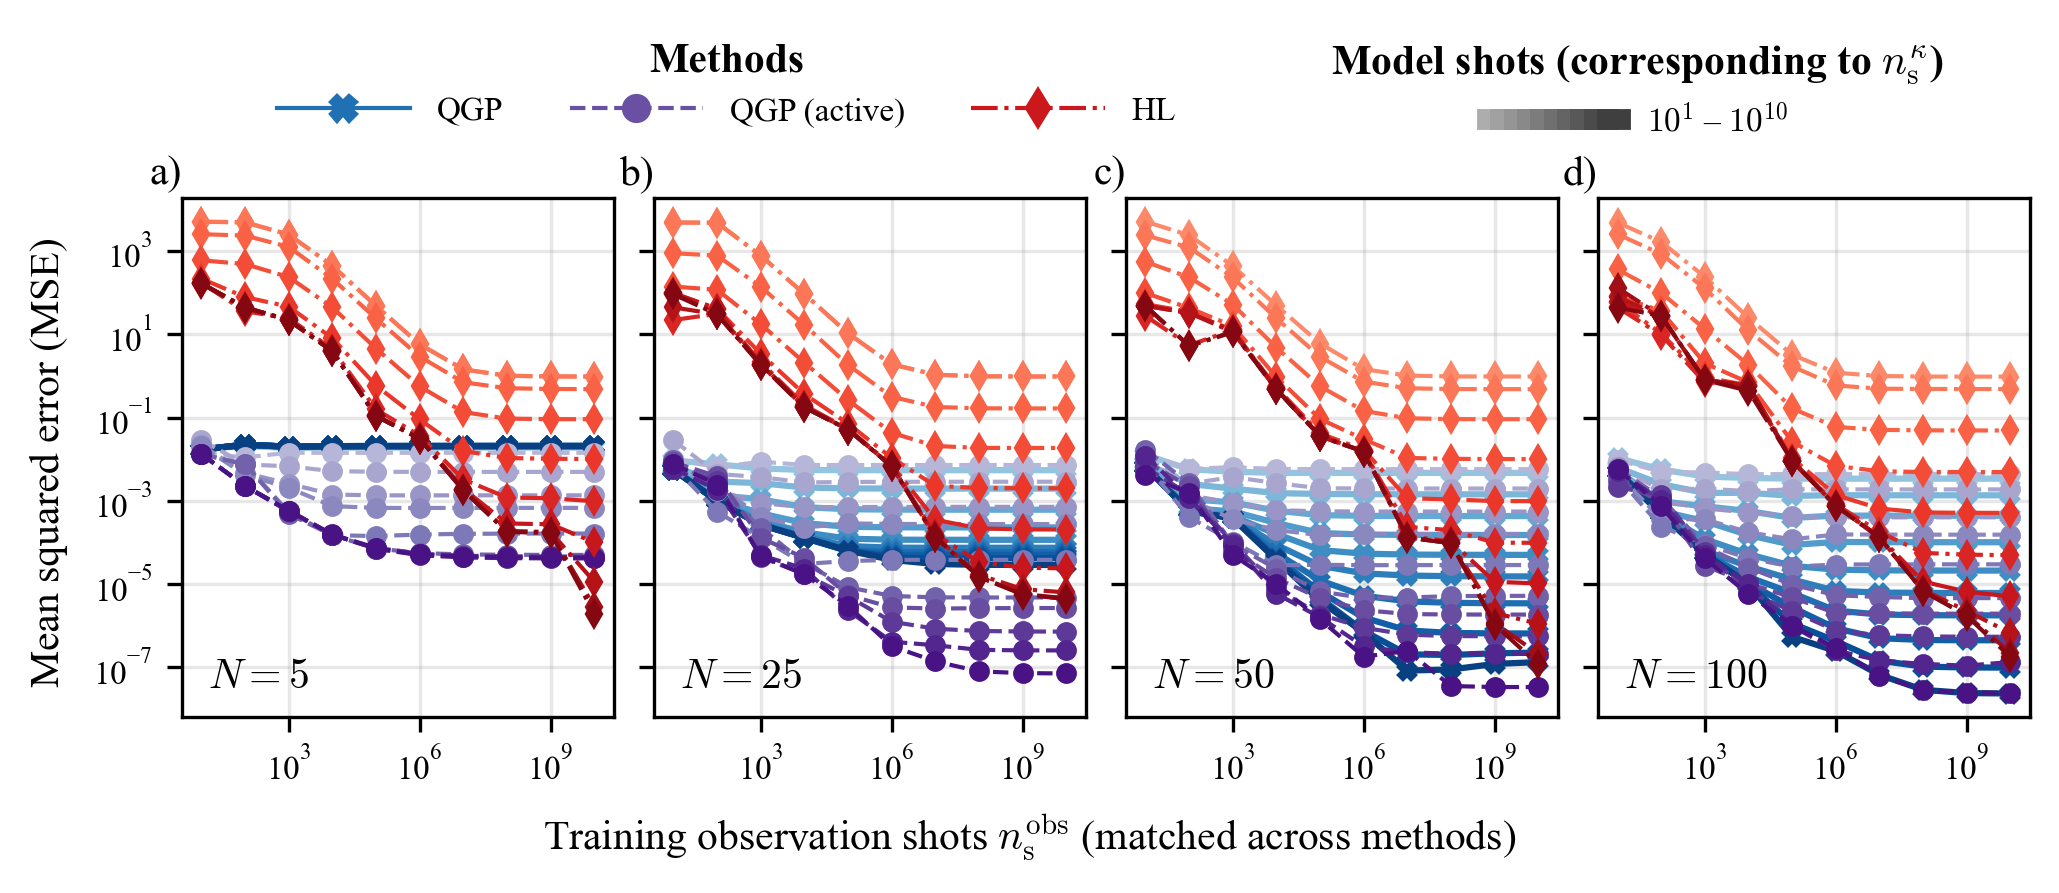

In [11]:
# Grid layout for subplots
N_ROWS = 1
N_COLS = 4

# Figure configuration
HEIGHT_INCHES = 2.3
LEGEND_NCOL = 3
LEGEND_ORDER = ['gp', 'gp_active', 'hl']

NTP_VALUES_PLOT = [5, 25, 50, 100]  # Values to plot

ACTUAL_NSHOTS_OBS = 10.0 ** NSHOTS_OBS


fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(WIDTH_INCHES, HEIGHT_INCHES), 
                         sharex=True, sharey=True, layout="constrained")
#fig.get_layout_engine().set(wspace=0.05, hspace=0.05) 
axes = axes.flatten()

label_font_size = plt.rcParams['axes.labelsize']

for idx, ntp in enumerate(NTP_VALUES_PLOT):
    if idx >= len(axes): break  
    ax = axes[idx]
    
    for method in LEGEND_ORDER:
        config = plot_configs[method]
        method_data = data["metrics"][ntp][f"{method}_{METRIC_NAME}"]
        
        for j, ns_pred in enumerate(NSHOTS_PREDS):
            # Calculate intensity and get color from cmap
            color_intensity = 0.4 + 0.6 * (j / len(NSHOTS_PREDS))
            
            # Copy kwargs so we don't accidentally overwrite the base color globally
            line_kwargs = config["kwargs"].copy()
            line_kwargs["color"] = config["cmap"](color_intensity)
            
            y_values = method_data[:, j]
            ax.plot(ACTUAL_NSHOTS_OBS, y_values, **line_kwargs)

    ax_config = bench_args["axes"]
    ax.set_xscale(ax_config["xscale"])
    ax.set_yscale(ax_config["yscale"])
    ax.grid(True, **ax_config["grid_major"])
    ax.grid(True, **ax_config["grid_minor"])

    # panel label:
    panel_label = f"{chr(97 + idx)})"  # Convert 0 -> 'a', 1 -> 'b', etc.
    ax.text(+0.0, 1.01, panel_label, transform=ax.transAxes, 
            verticalalignment='bottom', horizontalalignment='right',
            #fontweight='bold', 
            in_layout=False,
            fontsize=label_font_size)

    # training data size label:
    ax.text(0.06, 0.04, f"$N={ntp}$", #f"$N={ntp}$ {plot_args['observations']['label']}", 
            transform=ax.transAxes, 
            #verticalalignment='top', horizontalalignment='right',
            verticalalignment='bottom', horizontalalignment='left',
            fontsize=label_font_size
            #bbox=dict(boxstyle='square,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
            )

for idx in range(len(NTP_VALUES_PLOT), len(axes)):
    axes[idx].set_visible(False)

# Labels using JSON
fig.supxlabel(bench_args["axes"]["xlabel_obs"],  fontsize=label_font_size)
fig.supylabel(bench_args["axes"]["ylabel_mse"], fontsize=label_font_size,
              y=0.6,
              verticalalignment='center')

method_proxy_handles = []
for method in LEGEND_ORDER:
    if method in QUANTUM_METHODS:
        conf = plot_configs[method]
        method_proxy_handles.append(
            Line2D([0], [0], color=conf["cmap"](0.75), marker=conf["marker"], markersize=6,
                   linestyle=conf["linestyle"], label=conf["label"])
        )

legends_y_pos = 1.25

fig.legend(handles=method_proxy_handles, loc='upper center', bbox_to_anchor=(0.35, legends_y_pos),     
               ncol=LEGEND_NCOL, title="Methods", frameon=False,              
               title_fontproperties={'weight': 'bold'}, handlelength=4.0)

gradient_lines = []
for j in range(len(NSHOTS_PREDS)):
    intensity = 0.4 + 0.6 * (j / len(NSHOTS_PREDS))
    gray_color = str(1.0 - (0.8 * intensity)) 
    gradient_lines.append(Line2D([0], [0], color=gray_color, linewidth=5))

gradient_label = f"$10^{{{NSHOTS_PREDS[0]}}}$ – $10^{{{NSHOTS_PREDS[-1]}}}$"
fig.legend(handles=[tuple(gradient_lines)], labels=[gradient_label],
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
               loc='upper center', bbox_to_anchor=(0.8, legends_y_pos),
               title=bench_args['axes']['xlabel_pred'],
               frameon=False, title_fontproperties={'weight': 'bold'},
               handlelength=4.0)
fig.get_layout_engine().set(wspace=0.05, hspace=0.05) 

if SAVE_PLOTS:
    plt.savefig("../plots/bench_small_multiples.pdf")
plt.show()

## Pareto front

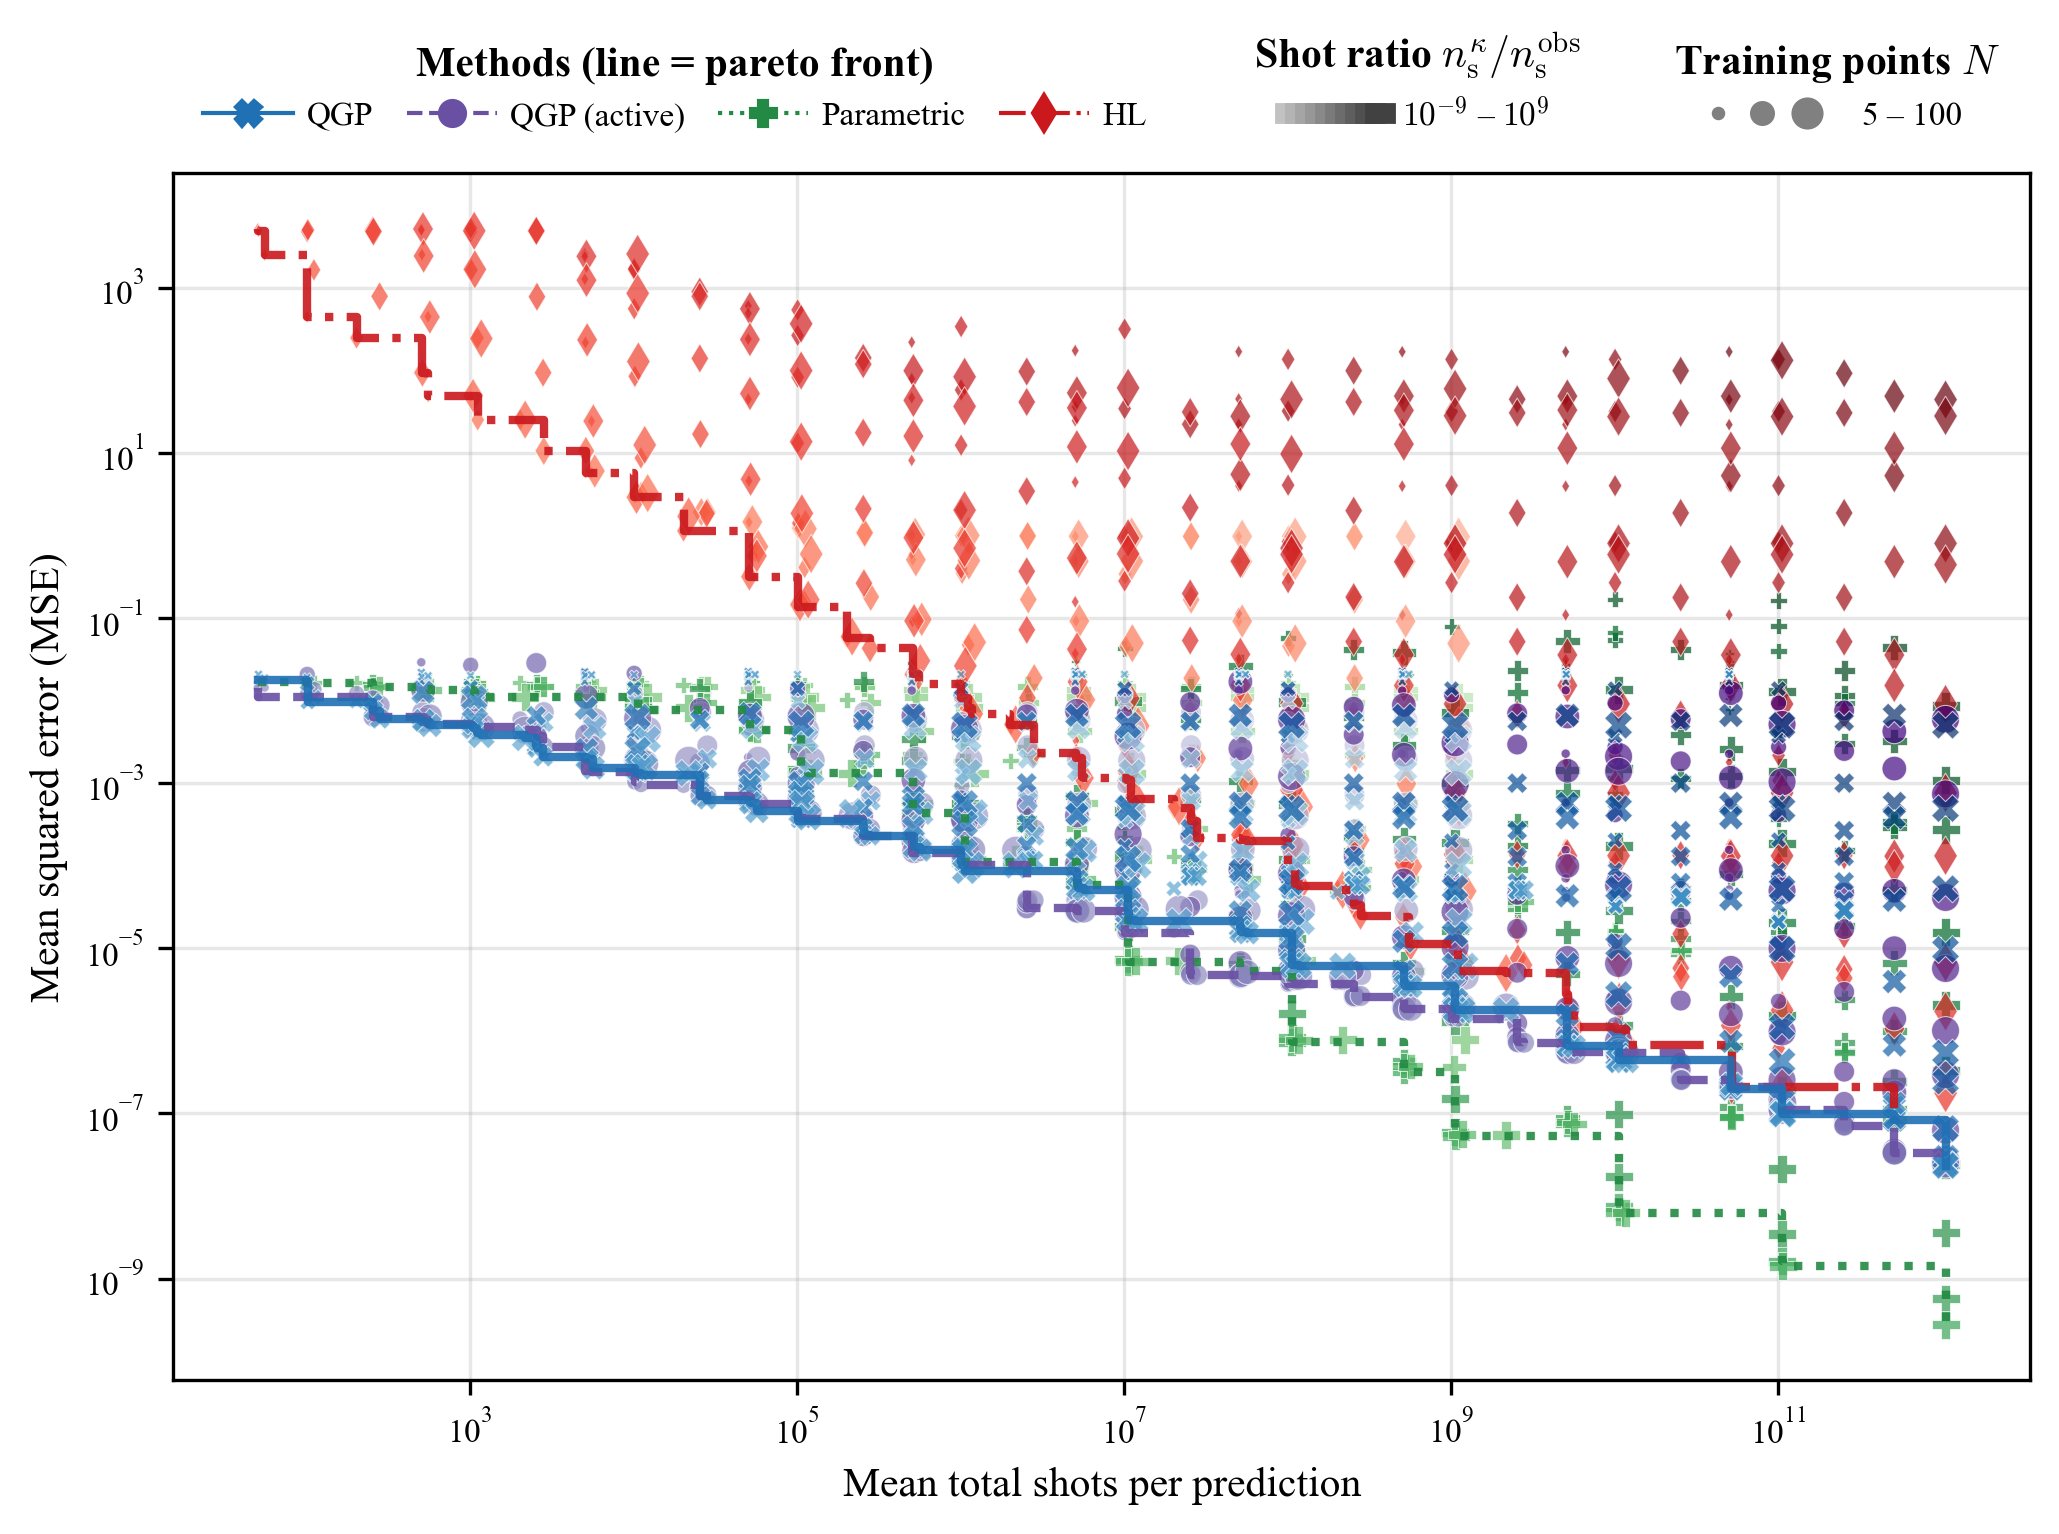

In [12]:
# =============================================================================
# Helper Function for Pareto Front (Lower Envelope)
# =============================================================================
def get_pareto_front(x, y):
    """Finds the bottom-left Pareto optimal points for Cost vs MSE."""
    sorted_indices = np.argsort(x)
    x_sorted = x[sorted_indices]
    y_sorted = y[sorted_indices]
    
    pareto_x = []
    pareto_y = []
    current_min_y = np.inf
    
    for xi, yi in zip(x_sorted, y_sorted):
        # Only add to the front if it strictly improves (lowers) the MSE
        if yi < current_min_y:
            pareto_x.append(xi)
            pareto_y.append(yi)
            current_min_y = yi
            
    return np.array(pareto_x), np.array(pareto_y)

# =============================================================================
# 1. MODIFIABLE CONFIGURATION
# =============================================================================
HEIGHT_INCHES = 5.0   

# Hardware / Domain setup
n_qubits = 50
m_val = 2
try:
    dsize = len(np.load(f'input/majo_n{n_qubits}_m{m_val}/times.npy'))
except FileNotFoundError:
    dsize = 1000

NTP_VALUES = sorted(data["ntps"][:5])

NSHOTS_OBS = np.arange(10) + 1    
NSHOTS_PREDS = np.arange(10) + 1  
ACTUAL_NSHOTS_OBS = 10.0 ** NSHOTS_OBS

# training point marker size:
MARKER_S_START = 5
MARKER_S_SLOPE = 10

METHODS_LEGEND_ORDER = ['gp', 'gp_active', 'param', 'hl']

# Calculate the absolute minimum and maximum log ratios for the color gradient
# If both range from 1 to 10, Min = 1 - 10 = -9. Max = 10 - 1 = 9.
MIN_LOG_RATIO = min(NSHOTS_PREDS) - max(NSHOTS_OBS)
MAX_LOG_RATIO = max(NSHOTS_PREDS) - min(NSHOTS_OBS)

# =============================================================================
# 2. RATIO-BASED PARETO PLOTTING LOGIC
# =============================================================================
fig, ax = plt.subplots(figsize=(WIDTH_INCHES, HEIGHT_INCHES), layout="constrained")

ax_config = bench_args["axes"]
ax.set_xscale(ax_config["xscale"])
ax.set_yscale(ax_config["yscale"])
ax.grid(True, **ax_config["grid_major"])
ax.grid(True, **ax_config["grid_minor"])

for method in reversed(QUANTUM_METHODS):
    config = plot_configs[method]
    all_x, all_y = [], []
    
    for ntp_idx, ntp in enumerate(NTP_VALUES):
        s_area = MARKER_S_START + (ntp_idx * MARKER_S_SLOPE) 
        method_data = data["metrics"][ntp][f"{method}_mse"]
        
        for j, ns_pred in enumerate(NSHOTS_PREDS):
            actual_ns_pred = 10.0 ** ns_pred
            test_set_size = dsize - ntp
            obs_gp_budget = ntp * ACTUAL_NSHOTS_OBS
            prediction_gp_budget = (ntp * (ntp + 1) / 2 + ntp * test_set_size) * actual_ns_pred
            total_budget = obs_gp_budget + prediction_gp_budget
            total_budget /= test_set_size
            
            # --- NEW RATIO COLOR MATH ---
            # Calculate the array of log ratios for this specific prediction shot 
            # against all observation shots in the array
            log_ratios = ns_pred - NSHOTS_OBS 
            
            # Normalize to [0.3, 1.0] so the colormap doesn't turn perfectly white/invisible
            norm_ratios = (log_ratios - MIN_LOG_RATIO) / (MAX_LOG_RATIO - MIN_LOG_RATIO)
            color_intensities = 0.3 + 0.7 * norm_ratios
            
            # config["cmap"] can accept an array of intensities and return an array of colors!
            colors = config["cmap"](color_intensities)
            
            y_values = method_data[:, j]
            
            ax.scatter(
                total_budget, y_values, 
                marker=config["marker"], 
                c=colors,                # Pass the array of colors
                alpha=0.7,
                s=s_area, 
                edgecolors='white',
                linewidths=0.25,          
                zorder=config["kwargs"].get("zorder", 3),
                rasterized=True,
            )
            
            all_x.extend(total_budget)
            all_y.extend(y_values)
            
    all_x, all_y = np.array(all_x), np.array(all_y)
    pareto_x, pareto_y = get_pareto_front(all_x, all_y)
    
    ax.step(
        pareto_x, pareto_y, where='post',               
        color=config["cmap"](0.75), linestyle=config["linestyle"], 
        linewidth=2.0, alpha=0.9, zorder=config["kwargs"].get("zorder", 3) + 1 
    )

ax.set_xlabel(ax_config["xlabel_total"])
ax.set_ylabel(ax_config["ylabel_mse"])

# =============================================================================
# 3. THREE-PART HORIZONTAL LEGEND
# =============================================================================

# ---------------------------------------------------------
# 1. Methods Legend (Left-aligned)
# ---------------------------------------------------------
method_proxy_handles = []
for method in METHODS_LEGEND_ORDER:
    if method in plot_configs:  # Safety check
        conf = plot_configs[method]
        method_proxy_handles.append(
            Line2D([0], [0], color=conf["cmap"](0.75), marker=conf["marker"], 
                   linestyle=conf["linestyle"], linewidth=1.0, markersize=6,
                   label=conf["label"])
        )

legend1 = ax.legend(
    handles=method_proxy_handles, 
    loc='lower left', 
    bbox_to_anchor=(0.0, 1.01), 
    ncol=len(METHODS_LEGEND_ORDER),  # Forces them all onto one single line
    title="Methods (line = pareto front)",
    frameon=False, 
    title_fontproperties={'weight': 'bold'}, 
    handletextpad=0.4,
    columnspacing=1.,
    handlelength=2.7, 
)

# ---------------------------------------------------------
# 2. Ratio Legend (Center-aligned)
# ---------------------------------------------------------
gradient_lines = []
for j in range(len(NSHOTS_PREDS)):
    intensity = 0.3 + 0.7 * (j / len(NSHOTS_PREDS))
    gray_color = str(1.0 - (0.8 * intensity)) 
    gradient_lines.append(Line2D([0], [0], color=gray_color, linewidth=5))

gradient_label = f"$10^{{{MIN_LOG_RATIO}}}$ – $10^{{{MAX_LOG_RATIO}}}$"
legend2 = ax.legend(
    handles=[tuple(gradient_lines)], labels=[gradient_label],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
    loc='lower center', 
    bbox_to_anchor=(0.67, 1.01), 
    title=r"Shot ratio $n_{\rm s}^{\kappa} / n_{\rm s}^{\rm obs}$", 
    frameon=False, 
    title_fontproperties={'weight': 'bold'}, 
    handlelength=3.0, 
    handletextpad=0.5
)

# ---------------------------------------------------------
# 3. Training Points Legend (Right-aligned, Min-Max Tuple)
# ---------------------------------------------------------
# Calculate the size of the first (smallest) and last (largest) markers
s_min_area = MARKER_S_START
s_mid_area = MARKER_S_START + ((len(NTP_VALUES) - 1) * MARKER_S_SLOPE) / 2
s_max_area = MARKER_S_START + ((len(NTP_VALUES) - 1) * MARKER_S_SLOPE)

# Create two individual proxy markers
min_marker = Line2D([0], [0], color='gray', marker='o', linestyle='None', markersize=np.sqrt(s_min_area))
mid_marker = Line2D([0], [0], color='gray', marker='o', linestyle='None', markersize=np.sqrt(s_mid_area))
max_marker = Line2D([0], [0], color='gray', marker='o', linestyle='None', markersize=np.sqrt(s_max_area))

ntp_label = f"{NTP_VALUES[0]} – {NTP_VALUES[-1]}"

legend3 = ax.legend(
    handles=[(min_marker, mid_marker, max_marker)], 
    labels=[ntp_label],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=1.)}, 
    loc='lower right', 
    bbox_to_anchor=(1.0, 1.01), 
    title="Training points $N$",
    frameon=False, 
    title_fontproperties={'weight': 'bold'}, 
    handletextpad=1.5,
    handlelength=3.0, 
)

ax.add_artist(legend1) 
ax.add_artist(legend2)

if SAVE_PLOTS:
    plt.savefig("../plots/total_pareto.pdf")
plt.show()